# HH-PC Benchmark: MNIST · FMNIST · N-MNIST

Two-layer **Hodgkin–Huxley spiking network trained with Predictive Coding**, evaluated on four datasets.

Everything is built on top of your `hhpc_base.py` — the neuron dynamics, PC inference, and PC learning rule are imported unchanged. This notebook only adds the parts that were stripped out of the base file: extra dataset loaders, operation counting, ROC-AUC, and per-epoch curves.

**What you get per dataset**

| Output | Where it comes from |
|---|---|
| Accuracy | PC-inference readout (`argmax` of the settled output layer), plus the feed-forward rate readout for reference |
| Macro F1 | Recomputed with scikit-learn (macro + weighted) |
| SOP count | Spike-driven synaptic operations, measured from real spike counts on the test set |
| FLOP count | HH membrane dynamics + PC inference matmuls, plus a dense-ANN equivalent baseline |
| ROC-AUC curve | One-vs-rest per class + macro/micro average |
| Loss curve / epoch | PC free energy on train and validation splits |
| Accuracy curve / epoch | Train-subset and validation accuracy |

**Before you run**

1. Put `hhpc_base.py` in the same folder as this notebook.
2. `pip install torch torchvision scikit-learn matplotlib numpy tonic`
   (`tonic` is only needed for N-MNIST.)
3. Start with `QUICK_MODE = True` in the config cell to smoke-test the whole pipeline in a few minutes, then flip it to `False` for the real run.



In [1]:
import sys, glob, shutil
hits = glob.glob("/kaggle/input/**/hhpc_base.py", recursive=True)
print("found:", hits)
shutil.copy(hits[0], "/kaggle/working/hhpc_base.py")
sys.path.insert(0, "/kaggle/working")

found: ['/kaggle/input/datasets/majordallim/hhpc-base/hhpc_base.py']


In [2]:
!pip install tonic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.2/106.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.9/131.9 kB 8.8 MB/s eta 0:00:00
  Created wheel for expelliarmus: filename=expelliarmus-1.1.12-cp312-cp312-linux_x86_64.whl size=56491 sha256=d283608e6b25fba865a8904655285abd87627f95bf9b992e58f8030ecd71865e
  Stored in directory: /root/.cache/pip/wheels/9a/9e/4b/f96da4dab397e63f90078766122e078e4ba82b2b48e07ee644
Successfully built expelliarmus
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency con

In [1]:
#@title Imports and environment check
import os, sys, time, json, math, warnings, copy
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets, transforms

import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, roc_auc_score,
                             f1_score, accuracy_score, confusion_matrix)

warnings.filterwarnings("ignore", category=UserWarning)

# --- import the untouched base model -------------------------------------
sys.path.insert(0, os.path.abspath("."))
try:
    from hhpc_base import (HHNeuron, PCSNNet, MetricAccumulator, EarlyStopper,
                           make_pc_activation, one_hot, set_seed, default_device)
except ModuleNotFoundError as err:
    raise ModuleNotFoundError(
        "hhpc_base.py must sit next to this notebook. "
        "Copy it into the working directory and re-run this cell."
    ) from err

#--- optional: tonic, only needed for N-MNIST ----------------------------
try:
    import tonic
    import tonic.transforms as tonic_tf
    HAS_TONIC = True
except Exception:
    HAS_TONIC = False

DEVICE = default_device()
print(f"torch      : {torch.__version__}")
print(f"device     : {DEVICE}")
if DEVICE.startswith("cuda"):
    print(f"gpu        : {torch.cuda.get_device_name(0)}")
print(f"tonic      : {'available' if HAS_TONIC else 'MISSING -> N-MNIST will be skipped (pip install tonic)'}")

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "font.size": 9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "figure.facecolor": "white",
})

torch      : 2.10.0+cu128
device     : cuda
gpu        : Tesla T4
tonic      : available


## 1. Configuration

`QUICK_MODE = True` shrinks every dataset to a few thousand samples and runs 2 epochs. It exercises every code path — loaders, training, op counting, ROC, plots — in a few minutes so you can catch bugs before committing GPU hours. Set it to `False` for the numbers you would actually report.

The HH-PC forward pass simulates `steps_spk` membrane timesteps *and* runs `T_infer` predictive-coding iterations per batch, so the full run is genuinely expensive. On an RTX PRO 6000 expect roughly 1.5–3 h per 10-class dataset at the full settings below.

In [2]:
#@title Global configuration
QUICK_MODE = False          # <<< flip to False for the full run

DATA_ROOT   = "./data"
OUT_DIR     = "./hhpc_results"
CKPT_DIR    = "./hhpc_ckpts"
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(OUT_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# Point this at an extracted 101_ObjectCategories folder if the auto-download fails.
CALTECH_LOCAL_DIR = None   # e.g. "./data/caltech101/101_ObjectCategories"


@dataclass
class RunCfg:
    """One experiment = one dataset + its hyper-parameters."""
    name: str
    input_dim: int
    num_classes: int
    hidden: int = 512
    steps_spk: int = 60           # membrane simulation timesteps
    T_infer_train: int = 100       # PC relaxation iterations while learning
    T_infer_eval: int = 50         # PC relaxation iterations at test time
    eta_x: float = 0.05            # PC state step size
    epochs: int = 30
    batch_size: int = 128
    lr: float = 2e-4
    weight_decay: float = 1e-4
    current_gain: float = 30.0
    I_bias: float = 2.0
    thr: float = 1.2
    dt: float = 0.03
    pc_activation: str = "relu"
    input_encoding: str = "poisson"   # "poisson" | "latency_first" | "event"
    poisson_scale: float = 1.0
    patience: int = 4
    seed: int = 42
    train_acc_batches: int = 20    # batches used for the per-epoch train-accuracy curve
    max_train: Optional[int] = None
    max_test: Optional[int] = None


def quickify(cfg: RunCfg) -> RunCfg:
    """Shrink a config so the whole pipeline runs in minutes."""
    c = copy.deepcopy(cfg)
    c.epochs = 2
    c.steps_spk = min(c.steps_spk, 15)
    c.T_infer_train = 20
    c.T_infer_eval = 10
    c.hidden = 128
    c.max_train = 2000
    c.max_test = 1000
    c.train_acc_batches = 4
    return c


CONFIGS: Dict[str, RunCfg] = {
    "MNIST":    RunCfg(name="MNIST",    input_dim=28 * 28,   num_classes=10),
    "FMNIST":   RunCfg(name="FMNIST",   input_dim=28 * 28,   num_classes=10),
    # Faces vs Motorbikes -> binary. Small dataset, so more epochs and a smaller net.
    # N-MNIST is genuinely event-based: 34x34 x 2 polarities = 2312 input channels.
    # steps_spk doubles as the number of temporal bins the events are folded into.
    "NMNIST":   RunCfg(name="NMNIST",   input_dim=34 * 34 * 2, num_classes=10,
                       input_encoding="event", steps_spk=50, batch_size=64),
}

if QUICK_MODE:
    CONFIGS = {k: quickify(v) for k, v in CONFIGS.items()}

print(f"QUICK_MODE = {QUICK_MODE}")
for k, v in CONFIGS.items():
    print(f"  {k:8s} in={v.input_dim:5d}  C={v.num_classes:2d}  hidden={v.hidden:4d}  "
          f"epochs={v.epochs:2d}  steps_spk={v.steps_spk:3d}  enc={v.input_encoding}")

QUICK_MODE = False
  MNIST    in=  784  C=10  hidden= 512  epochs=30  steps_spk= 60  enc=poisson
  FMNIST   in=  784  C=10  hidden= 512  epochs=30  steps_spk= 60  enc=poisson
  NMNIST   in= 2312  C=10  hidden= 512  epochs=30  steps_spk= 50  enc=event


## 2. Data

Three loader families, all returning `(train, val, test)` DataLoaders:

- **MNIST / FMNIST** — torchvision, 28×28 grayscale in `[0,1]`, 90/10 train-val split. The model turns these into Poisson spike trains internally.
- **Caltech101 Faces vs Motorbikes** — filtered to the two categories, converted to grayscale, resized to 28×28 so the same 784-input architecture applies. Stratified 70/10/20 split, because Caltech ships no official test set.
- **N-MNIST** — real event data, not a converted image. Events are binned into `steps_spk` temporal frames of shape `(2, 34, 34)`, binarised, and flattened to a `(2312, steps_spk)` spike train that is fed straight into the network. No synthetic Poisson encoding is used here, which is the whole point of benchmarking on it.

Each sample from a loader is either a `(B, 1, H, W)` image or a `(B, D, T)` spike train; `prep_x` below normalises both into what the network expects.

In [3]:
#@title Loaders: MNIST / FMNIST / Caltech101 (Faces vs Motorbikes)
from PIL import Image
import glob


def _subsample(ds, n: Optional[int], seed: int = 0):
    """Deterministically keep at most n samples (used by QUICK_MODE)."""
    if n is None or n >= len(ds):
        return ds
    g = np.random.RandomState(seed)
    idx = g.permutation(len(ds))[:n]
    return Subset(ds, idx.tolist())


def _mk_loaders(train_ds, val_ds, test_ds, batch_size, device, seed=42):
    use_cuda = str(device).startswith("cuda") and torch.cuda.is_available()
    kw = dict(num_workers=4 if use_cuda else 0,
              pin_memory=use_cuda,
              persistent_workers=bool(use_cuda))
    g = torch.Generator().manual_seed(seed)
    return (
        DataLoader(train_ds, batch_size, shuffle=True, drop_last=False, generator=g, **kw),
        DataLoader(val_ds,   batch_size, shuffle=False, **kw),
        DataLoader(test_ds,  batch_size, shuffle=False, **kw),
    )


# ── MNIST / FMNIST ───────────────────────────────────────────────────────
def get_image_loaders(cfg: RunCfg, device: str):
    tfm = transforms.ToTensor()
    ctor = datasets.FashionMNIST if cfg.name.upper() in ("FMNIST", "FASHIONMNIST") else datasets.MNIST
    train_full = ctor(root=DATA_ROOT, train=True,  download=True, transform=tfm)
    test_ds    = ctor(root=DATA_ROOT, train=False, download=True, transform=tfm)

    n_val = max(1, int(round(0.1 * len(train_full))))
    g = torch.Generator().manual_seed(cfg.seed)
    train_ds, val_ds = random_split(train_full, [len(train_full) - n_val, n_val], generator=g)

    train_ds = _subsample(train_ds, cfg.max_train, cfg.seed)
    val_ds   = _subsample(val_ds,   None if cfg.max_train is None else max(200, cfg.max_train // 5), cfg.seed)
    test_ds  = _subsample(test_ds,  cfg.max_test, cfg.seed)
    return _mk_loaders(train_ds, val_ds, test_ds, cfg.batch_size, device, cfg.seed)



_caltech_tfm = transforms.Compose([
    transforms.Lambda(lambda im: im.convert("L")),   # some Caltech images are RGB, some already L
    transforms.Resize((28, 28)),
    transforms.ToTensor(),                            # -> (1,28,28) in [0,1]
])


class _PathImageDataset(Dataset):
    """Minimal image-folder dataset used by the manual Caltech fallback."""

    def __init__(self, paths: List[str], labels: List[int], transform):
        self.paths, self.labels, self.transform = paths, labels, transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i])
        return self.transform(img), int(self.labels[i])


def _caltech_from_local(root_dir: str):
    paths, labels = [], []
    for lab, canonical in enumerate(CALTECH_CLASSES):
        found = None
        for alias in CALTECH_ALIASES[canonical]:
            cand = os.path.join(root_dir, alias)
            if os.path.isdir(cand):
                found = cand
                break
        if found is None:
            raise FileNotFoundError(f"No folder for '{canonical}' under {root_dir}")
        files = sorted(glob.glob(os.path.join(found, "*.jpg")) +
                       glob.glob(os.path.join(found, "*.png")))
        paths += files
        labels += [lab] * len(files)
    return _PathImageDataset(paths, labels, _caltech_tfm)


def _caltech_from_torchvision():
    base = datasets.Caltech101(root=DATA_ROOT, target_type="category",
                               download=True, transform=_caltech_tfm)
    cats = list(base.categories)
    name_to_label, keep_cat_idx = {}, {}
    for lab, canonical in enumerate(CALTECH_CLASSES):
        hit = next((a for a in CALTECH_ALIASES[canonical] if a in cats), None)
        if hit is None:
            raise RuntimeError(f"Category '{canonical}' not found in Caltech101")
        keep_cat_idx[cats.index(hit)] = lab
        name_to_label[hit] = lab

    idx = [i for i, y in enumerate(base.y) if y in keep_cat_idx]
    labels = [keep_cat_idx[base.y[i]] for i in idx]

    class _Remapped(Dataset):
        def __len__(self_inner):
            return len(idx)

        def __getitem__(self_inner, j):
            img, _ = base[idx[j]]
            return img, labels[j]

    print(f"  Caltech categories used: {name_to_label}")
    return _Remapped(), labels


def get_caltech_loaders(cfg: RunCfg, device: str):
    """Binary Faces-vs-Motorbikes, stratified 70/10/20 split."""
    ds, labels = None, None
    if CALTECH_LOCAL_DIR and os.path.isdir(CALTECH_LOCAL_DIR):
        ds = _caltech_from_local(CALTECH_LOCAL_DIR)
        labels = ds.labels
        print(f"  Caltech loaded from local dir: {CALTECH_LOCAL_DIR}")
    else:
        try:
            ds, labels = _caltech_from_torchvision()
        except Exception as e:
            raise RuntimeError(
                "Caltech101 auto-download failed (this is usually a Google Drive quota error).\n"
                "Download 101_ObjectCategories.tar.gz manually, extract it, and set\n"
                "CALTECH_LOCAL_DIR = '<path>/101_ObjectCategories' in the config cell.\n"
                f"Underlying error: {e}"
            ) from e

    labels = np.asarray(labels)
    rng = np.random.RandomState(cfg.seed)
    tr_idx, va_idx, te_idx = [], [], []
    for c in np.unique(labels):                      # stratify so the split keeps class balance
        ci = np.where(labels == c)[0]
        rng.shuffle(ci)
        n = len(ci)
        n_tr, n_va = int(0.7 * n), int(0.1 * n)
        tr_idx += ci[:n_tr].tolist()
        va_idx += ci[n_tr:n_tr + n_va].tolist()
        te_idx += ci[n_tr + n_va:].tolist()

    counts = {int(c): int((labels == c).sum()) for c in np.unique(labels)}
    print(f"  Caltech class counts (0=Faces, 1=Motorbikes): {counts}  "
          f"| split train/val/test = {len(tr_idx)}/{len(va_idx)}/{len(te_idx)}")

    train_ds = _subsample(Subset(ds, tr_idx), cfg.max_train, cfg.seed)
    val_ds   = Subset(ds, va_idx)
    test_ds  = _subsample(Subset(ds, te_idx), cfg.max_test, cfg.seed)
    return _mk_loaders(train_ds, val_ds, test_ds, cfg.batch_size, device, cfg.seed)

In [4]:
#@title Loader: N-MNIST (real events -> binned spike trains)

class NMNISTSpikeTrain(Dataset):
    """Wraps a tonic N-MNIST dataset and emits a (D, T) uint8 spike train.

    tonic's ToFrame gives us (T, 2, 34, 34) event counts. We binarise
    (a pixel either spiked in that bin or it did not), flatten the spatial +
    polarity axes into D = 2*34*34 = 2312, and transpose to (D, T) so the
    network can index timestep t as spk_train[:, :, t] exactly like the
    Poisson trains it builds for the image datasets.

    uint8 keeps host->device transfer ~4x cheaper; we cast to float on GPU.
    """

    def __init__(self, base):
        self.base = base

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        frames, y = self.base[i]
        f = torch.as_tensor(np.asarray(frames))          # (T, 2, 34, 34)
        T = f.shape[0]
        f = (f > 0).to(torch.uint8).reshape(T, -1).t().contiguous()   # (D, T)
        return f, int(y)


def get_nmnist_loaders(cfg: RunCfg, device: str):
    if not HAS_TONIC:
        raise RuntimeError("tonic is not installed. Run: pip install tonic")

    sensor_size = tonic.datasets.NMNIST.sensor_size          # (34, 34, 2)
    frame_tf = tonic_tf.Compose([
        tonic_tf.Denoise(filter_time=10000),                 # drop isolated hot-pixel events
        tonic_tf.ToFrame(sensor_size=sensor_size, n_time_bins=cfg.steps_spk),
    ])

    train_full = tonic.datasets.NMNIST(save_to=DATA_ROOT, train=True,  transform=frame_tf)
    test_raw   = tonic.datasets.NMNIST(save_to=DATA_ROOT, train=False, transform=frame_tf)

    # Cache the binned frames on disk: event decoding is the bottleneck, not the model.
    cache_tag = f"nmnist_T{cfg.steps_spk}"
    try:
        train_full = tonic.DiskCachedDataset(train_full, cache_path=f"{DATA_ROOT}/cache/{cache_tag}_train")
        test_raw   = tonic.DiskCachedDataset(test_raw,   cache_path=f"{DATA_ROOT}/cache/{cache_tag}_test")
    except Exception as e:
        print(f"  (disk cache unavailable, continuing uncached: {e})")

    train_full = NMNISTSpikeTrain(train_full)
    test_ds    = NMNISTSpikeTrain(test_raw)

    n_val = max(1, int(round(0.1 * len(train_full))))
    g = torch.Generator().manual_seed(cfg.seed)
    train_ds, val_ds = random_split(train_full, [len(train_full) - n_val, n_val], generator=g)

    train_ds = _subsample(train_ds, cfg.max_train, cfg.seed)
    val_ds   = _subsample(val_ds, None if cfg.max_train is None else max(200, cfg.max_train // 5), cfg.seed)
    test_ds  = _subsample(test_ds, cfg.max_test, cfg.seed)

    print(f"  N-MNIST: D={sensor_size[0]*sensor_size[1]*sensor_size[2]}, T={cfg.steps_spk} bins, "
          f"train/val/test = {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
    return _mk_loaders(train_ds, val_ds, test_ds, cfg.batch_size, device, cfg.seed)


# ── single entry point ───────────────────────────────────────────────────
def get_loaders_for(cfg: RunCfg, device: str):
    n = cfg.name.upper()
    if n == "CALTECH":
        return get_caltech_loaders(cfg, device)
    if n == "NMNIST":
        return get_nmnist_loaders(cfg, device)
    return get_image_loaders(cfg, device)


def prep_x(x: torch.Tensor, device: str) -> torch.Tensor:
    """Images -> (B, D) floats in [0,1];  event trains -> (B, D, T) floats in {0,1}."""
    x = x.to(device, non_blocking=True).float()
    if x.dim() == 3:          # (B, D, T) spike train, already binary
        return x
    return x.view(x.size(0), -1)

## 3. Model extension

`PCSNNetX` subclasses `PCSNNet` from the base file. It changes two things and nothing else:

1. **Event input.** If the batch arrives as `(B, D, T)` it is used directly as the input spike train, bypassing the internal Poisson/latency encoder. The PC input node `x[0]` becomes the time-averaged firing rate of that train, which is exactly what the Poisson path produces for images, so the PC machinery downstream is untouched.
2. **Input spike accounting.** The base records hidden and output spike sums but not how many input spikes were injected. SOP counting needs that number, so we store it.

HH dynamics, PC inference, and the PC learning rule are inherited verbatim.

In [5]:
#@title PCSNNetX: event-capable network with spike accounting

class PCSNNetX(PCSNNet):
    """PCSNNet + external event input + input-spike bookkeeping."""

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._last_input_spikes: float = 0.0   # total input spikes in the last forward
        self._last_batch: int = 0
        self._last_steps: int = 0

    @torch.no_grad()
    def forward_proxies(self, x_in: torch.Tensor, steps_spk: int) -> List[torch.Tensor]:
        x_in = x_in.to(self.device)

        # ---- 1. obtain the input spike train (B, D, T) ----------------------
        if x_in.dim() == 3:
            # Real events (N-MNIST). Already binary, already temporal.
            spk_train = (x_in > 0).float()
            B, _, steps_spk = spk_train.shape
            x0 = spk_train.mean(-1).clamp(0, 1)         # rate proxy for the PC input node
            mode = "event"
        else:
            x0 = x_in.clamp(0, 1)
            B = x0.size(0)
            if self.input_encoding == "latency_first":
                lat = self._encode_latency(x0, steps_spk)
                spk_train = self._build_spike_train(lat, steps_spk)
                fired = torch.zeros_like(x0, dtype=torch.bool)
                mode = "latency_first"
            else:
                p = (x0 * self.poisson_scale).clamp(0, 1)
                spk_train = (torch.rand(B, x0.size(1), steps_spk, device=self.device)
                             < p.unsqueeze(-1)).float()
                mode = "poisson"

        for cell in self.cells:
            cell.reset_states(B)

        spike_sums = [torch.zeros(B, self.sizes[i + 1], device=self.device)
                      for i in range(self.S)]
        input_spikes = 0.0

        # ---- 2. simulate the membrane dynamics -----------------------------
        for t in range(steps_spk):
            if mode == "latency_first":
                inp = (spk_train[:, :, t] * (~fired)).float()
                fired.logical_or_(inp.bool())
            else:
                inp = spk_train[:, :, t]

            input_spikes += float(inp.sum())

            r = inp
            for i in range(self.S):
                h = F.linear(r, self.syn[i].weight, self.syn[i].bias)
                I = h * self.current_gain + self.I_bias
                spk, _ = self.cells[i](I)
                spike_sums[i] += spk
                r = spk

        self._last_spike_sums = spike_sums
        self._last_input_spikes = input_spikes
        self._last_batch = B
        self._last_steps = steps_spk

        return [x0] + [(ss / float(steps_spk)).clamp(0, 1) for ss in spike_sums]

    def last_input_spikes(self) -> float:
        return self._last_input_spikes


def build_model(cfg: RunCfg, device: str) -> PCSNNetX:
    set_seed(cfg.seed)
    layer_sizes = [cfg.input_dim, cfg.hidden, cfg.num_classes]
    model = PCSNNetX(
        layer_sizes=layer_sizes,
        dt=cfg.dt,
        device=device,
        current_gain=cfg.current_gain,
        I_bias=cfg.I_bias,
        thr=cfg.thr,
        pc_activation=cfg.pc_activation,
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
        input_encoding=("poisson" if cfg.input_encoding == "event" else cfg.input_encoding),
        poisson_scale=cfg.poisson_scale,
    ).to(device)
    n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  model: {layer_sizes}  |  {n_par:,} trainable params")
    return model

## 4. FLOP and SOP counting

"FLOPs" and "SOPs" get thrown around loosely in SNN papers, so here is exactly what is counted. Every number is **per test sample** and the spike counts are *measured*, not assumed.

**SOPs — synaptic operations.** A spiking synapse only does work when a presynaptic spike arrives, and the work is an accumulate, not a multiply. So for layer $\ell$:

$$\text{SOP}_\ell = (\text{total presynaptic spikes into } \ell) \times (\text{fan-out of } \ell)$$

Layer 0's presynaptic spikes are the input spike train (Poisson for images, real events for N-MNIST); layer 1's are the hidden layer's emitted spikes. This is the quantity that scales neuromorphic energy.

**FLOPs.** Three things in this model are genuinely dense arithmetic and must be charged as FLOPs:

1. *HH membrane dynamics* — six gating rate functions with exponentials, three gate integrations, three ionic currents, the Euler step, the `tanh` squash, and spike/refractory logic. Charged per neuron per simulation timestep. This is what makes HH expensive relative to LIF, so hiding it would be dishonest.
2. *Bias and current scaling* — `h * gain + I_bias` is applied densely every timestep.
3. *PC inference* — the relaxation loop is dense matrix algebra: a forward prediction per layer plus a feedback projection per hidden layer, repeated `T_infer` times.

**Dense-ANN baseline.** For reference we also report the FLOPs an equivalent non-spiking MLP of the same shape would need for one forward pass, $2\sum_\ell n_\ell n_{\ell+1}$.

**Energy estimate.** Using the widely cited 45 nm 32-bit figures (Horowitz, ISSCC 2014): one MAC ≈ 4.6 pJ, one accumulate ≈ 0.9 pJ. We charge SOPs at the accumulate rate and FLOPs at the MAC rate (two FLOPs per MAC). Treat this as an order-of-magnitude comparison between conditions, not a hardware measurement.

The exponential and `tanh` costs are the only free parameters; they are exposed below so you can state them in a paper.

In [6]:
#@title Operation counters

EXP_COST  = 10.0    # FLOPs charged for one transcendental exp()
TANH_COST = 10.0    # FLOPs charged for one tanh()
E_MAC_PJ  = 4.6     # 45nm 32-bit multiply-accumulate
E_AC_PJ   = 0.9     # 45nm 32-bit accumulate


def hh_flops_per_neuron_step(exp_cost=EXP_COST, tanh_cost=TANH_COST) -> Dict[str, float]:
    """FLOPs for one HHNeuron.forward() update of a single neuron.

    Derived line-by-line from HHNeuron in hhpc_base.py.
    """
    gates_rates = 2 + (6 + exp_cost) + (3 + exp_cost) + (6 + exp_cost) \
                    + (3 + exp_cost) + (3 + exp_cost) + (4 + exp_cost)   # _update_gates
    gates_integrate = 3 * (6 + 2)          # s + dt*(a(1-s) - b*s), then clamp
    ionic = 6 + 5 + 2                       # INa, IK, ILeak
    euler = 4 + 2 + (2 + tanh_cost)         # dV, V + dt*dV, tanh squash
    spike_logic = 7                         # threshold compare, reset, refractory update
    total = gates_rates + gates_integrate + ionic + euler + spike_logic
    return {"gate_rates": gates_rates, "gate_integrate": gates_integrate,
            "ionic": ionic, "euler_squash": euler, "spike_logic": spike_logic,
            "total": total}


def pc_inference_flops(sizes: List[int], T_infer: int) -> float:
    """Dense FLOPs for T_infer predictive-coding relaxation iterations (per sample)."""
    L = len(sizes) - 1
    per_iter = 0.0
    for l in range(L):                       # forward prediction z = W x + b, e = x - f(z)
        per_iter += 2.0 * sizes[l] * sizes[l + 1]      # matmul
        per_iter += 3.0 * sizes[l + 1]                 # bias + f(z) + subtraction
    for l in range(1, L):                    # feedback into hidden states only
        per_iter += 2.0 * sizes[l + 1]                 # e * f'(z)
        per_iter += 2.0 * sizes[l + 1] * sizes[l]      # matmul back
    for l in range(1, L + 1):                # state update + clamp
        per_iter += 4.0 * sizes[l]
    return per_iter * T_infer


def ann_equivalent_flops(sizes: List[int]) -> float:
    """One forward pass of a dense MLP of the same shape."""
    return sum(2.0 * sizes[i] * sizes[i + 1] for i in range(len(sizes) - 1))


@torch.no_grad()
def count_ops(model: PCSNNetX, loader, device: str, cfg: RunCfg,
              eval_seed: int = 1234) -> Dict[str, Any]:
    """Measure real spike counts on `loader`, then convert to SOPs / FLOPs per sample."""
    model.eval()
    sizes = model.sizes
    S = model.S

    tot_input_spk = 0.0
    tot_layer_spk = [0.0] * S
    tot_denom     = [0.0] * S
    n_samples = 0
    steps_used = cfg.steps_spk

    with torch.random.fork_rng():
        torch.manual_seed(eval_seed)
        for x, _ in loader:
            x = prep_x(x, device)
            B = x.size(0)
            model.forward_proxies(x, cfg.steps_spk)
            ss = model.last_spike_sums()
            steps_used = model._last_steps
            tot_input_spk += model.last_input_spikes()
            for li in range(S):
                tot_layer_spk[li] += float(ss[li].sum())
                tot_denom[li]     += float(B * ss[li].shape[1] * steps_used)
            n_samples += B

    n = max(n_samples, 1)
    in_spk_ps  = tot_input_spk / n                       # input spikes per sample
    lay_spk_ps = [s / n for s in tot_layer_spk]          # spikes emitted per layer per sample

    # ── SOPs: presynaptic spikes x fan-out ──────────────────────────────
    sop_l0 = in_spk_ps    * sizes[1]
    sop_l1 = lay_spk_ps[0] * sizes[2]
    sops = sop_l0 + sop_l1

    # ── FLOPs ───────────────────────────────────────────────────────────
    hh = hh_flops_per_neuron_step()
    n_spiking_neurons = sizes[1] + sizes[2]
    flops_neuron = steps_used * n_spiking_neurons * hh["total"]
    flops_bias   = steps_used * n_spiking_neurons * 2.0      # h*gain + I_bias
    flops_pc     = pc_inference_flops(sizes, cfg.T_infer_eval)
    flops_total  = flops_neuron + flops_bias + flops_pc

    energy_pj = sops * E_AC_PJ + (flops_total / 2.0) * E_MAC_PJ

    return {
        "input_spikes_per_sample": in_spk_ps,
        "hidden_spikes_per_sample": lay_spk_ps[0],
        "output_spikes_per_sample": lay_spk_ps[1] if S > 1 else 0.0,
        "spike_rate_per_layer": [tot_layer_spk[i] / max(tot_denom[i], 1.0) for i in range(S)],
        "spike_rate_total": sum(tot_layer_spk) / max(sum(tot_denom), 1.0),
        "SOPs_layer1": sop_l0,
        "SOPs_layer2": sop_l1,
        "SOPs_per_sample": sops,
        "FLOPs_hh_dynamics": flops_neuron,
        "FLOPs_bias_current": flops_bias,
        "FLOPs_pc_inference": flops_pc,
        "FLOPs_per_sample": flops_total,
        "FLOPs_ann_equivalent": ann_equivalent_flops(sizes),
        "hh_flops_per_neuron_step": hh["total"],
        "energy_pJ_per_sample": energy_pj,
        "steps_spk_used": steps_used,
        "n_samples": n_samples,
    }


print("HH cost breakdown (FLOPs per neuron per timestep):")
for k, v in hh_flops_per_neuron_step().items():
    print(f"  {k:16s} {v:8.1f}")

HH cost breakdown (FLOPs per neuron per timestep):
  gate_rates           87.0
  gate_integrate       24.0
  ionic                13.0
  euler_squash         18.0
  spike_logic           7.0
  total               149.0


In [7]:
#@title Evaluation: accuracy, F1, PC energy, and class scores for ROC

@torch.no_grad()
def evaluate(model: PCSNNetX, loader, device: str, cfg: RunCfg,
             T_infer: Optional[int] = None, collect_scores: bool = True,
             max_batches: Optional[int] = None, eval_seed: int = 1234) -> Dict[str, Any]:
    """One evaluation pass.

    Two readouts are reported:
      ff_*  - the raw spike-rate of the output layer (feed-forward readout)
      pc_*  - the output layer after PC relaxation with the target unclamped
              (this is the model's actual prediction)
    The reported loss is the PC free energy with the target clamped, i.e. the
    same objective the learning rule descends.
    """
    model.eval()
    T_infer = cfg.T_infer_eval if T_infer is None else T_infer
    C = model.sizes[-1]

    ys, pc_scores, ff_scores, pc_preds, ff_preds = [], [], [], [], []
    total_energy, total_n = 0.0, 0

    with torch.random.fork_rng():
        torch.manual_seed(eval_seed)
        for bi, (x, y) in enumerate(loader):
            if max_batches is not None and bi >= max_batches:
                break
            x = prep_x(x, device)
            y = y.to(device)
            B = x.size(0)

            proxies = model.forward_proxies(x, cfg.steps_spk)

            ff_s = proxies[-1]                                   # (B, C) firing rates
            xs, _, _, _ = model.pc_infer(proxies, None, T_infer, cfg.eta_x, clamp_output=False)
            pc_s = xs[-1]                                        # (B, C) settled states

            # PC free energy with the label clamped == training objective
            _, _, _, energy = model.pc_infer(proxies, one_hot(y, C), T_infer,
                                             cfg.eta_x, clamp_output=True)
            total_energy += energy * B
            total_n += B

            ys.append(y.cpu())
            pc_preds.append(pc_s.argmax(1).cpu())
            ff_preds.append(ff_s.argmax(1).cpu())
            if collect_scores:
                pc_scores.append(pc_s.float().cpu())
                ff_scores.append(ff_s.float().cpu())

    y_true  = torch.cat(ys).numpy()
    y_pc    = torch.cat(pc_preds).numpy()
    y_ff    = torch.cat(ff_preds).numpy()

    out = {
        "loss": total_energy / max(total_n, 1),
        "pc_acc": float(accuracy_score(y_true, y_pc)),
        "ff_acc": float(accuracy_score(y_true, y_ff)),
        "pc_f1_macro":    float(f1_score(y_true, y_pc, average="macro", zero_division=0)),
        "pc_f1_weighted": float(f1_score(y_true, y_pc, average="weighted", zero_division=0)),
        "ff_f1_macro":    float(f1_score(y_true, y_ff, average="macro", zero_division=0)),
        "n": int(total_n),
        "y_true": y_true, "y_pred": y_pc, "y_pred_ff": y_ff,
    }

    if collect_scores:
        out["pc_probs"] = _to_probs(torch.cat(pc_scores).numpy(), C)
        out["ff_probs"] = _to_probs(torch.cat(ff_scores).numpy(), C)
    return out


def _to_probs(scores: np.ndarray, C: int, eps: float = 1e-12) -> np.ndarray:
    """Normalise non-negative class scores into rows that sum to 1.

    The output layer emits firing rates / settled states in [0, 1]; sklearn's
    one-vs-rest AUC wants proper probabilities. Rows that are all-zero (the
    network produced no output spikes at all) fall back to uniform, which
    scores as chance rather than silently biasing toward class 0.
    """
    s = np.clip(scores.astype(np.float64), 0.0, None)
    row = s.sum(axis=1, keepdims=True)
    dead = (row[:, 0] <= eps)
    s[dead] = 1.0 / C
    row = s.sum(axis=1, keepdims=True)
    return s / np.clip(row, eps, None)

In [8]:
#@title ROC / AUC utilities

def compute_roc(y_true: np.ndarray, probs: np.ndarray, C: int) -> Dict[str, Any]:
    """One-vs-rest ROC curves plus micro and macro averages.

    Binary case (Caltech): a single curve on the positive class.
    Multiclass: one curve per class, a micro average over all flattened
    decisions, and a macro average interpolated on a shared FPR grid.
    """
    y_onehot = np.eye(C, dtype=np.float64)[y_true.astype(int)]
    res: Dict[str, Any] = {"per_class": {}, "C": C}

    if C == 2:
        fpr, tpr, _ = roc_curve(y_true, probs[:, 1])
        a = auc(fpr, tpr)
        res["per_class"][1] = {"fpr": fpr, "tpr": tpr, "auc": a}
        res["binary"] = {"fpr": fpr, "tpr": tpr, "auc": a}
        res["macro_auc"] = a
        res["micro_auc"] = a
        return res

    aucs = []
    for c in range(C):
        if y_onehot[:, c].sum() == 0:          # class absent from this split
            continue
        fpr, tpr, _ = roc_curve(y_onehot[:, c], probs[:, c])
        a = auc(fpr, tpr)
        res["per_class"][c] = {"fpr": fpr, "tpr": tpr, "auc": a}
        aucs.append(a)

    fpr_micro, tpr_micro, _ = roc_curve(y_onehot.ravel(), probs.ravel())
    res["micro"] = {"fpr": fpr_micro, "tpr": tpr_micro, "auc": auc(fpr_micro, tpr_micro)}
    res["micro_auc"] = res["micro"]["auc"]

    grid = np.unique(np.concatenate([res["per_class"][c]["fpr"] for c in res["per_class"]]))
    mean_tpr = np.zeros_like(grid)
    for c in res["per_class"]:
        mean_tpr += np.interp(grid, res["per_class"][c]["fpr"], res["per_class"][c]["tpr"])
    mean_tpr /= max(len(res["per_class"]), 1)
    res["macro"] = {"fpr": grid, "tpr": mean_tpr, "auc": auc(grid, mean_tpr)}

    # sklearn's own macro OvR AUC, as a cross-check on the interpolated curve
    try:
        res["macro_auc"] = float(roc_auc_score(y_true, probs, multi_class="ovr", average="macro"))
    except Exception:
        res["macro_auc"] = float(np.mean(aucs)) if aucs else float("nan")
    return res

## 5. Training loop with per-epoch history

The PC learning rule needs no backprop graph — weights are updated from local prediction errors after the relaxation settles — so `train_step` is called under `no_grad` semantics inherited from the base file.

Per epoch we record four numbers:

- **train loss** — mean PC free energy over the training batches, collected for free during learning
- **val loss** — PC free energy on the validation split with the label clamped
- **train accuracy** — measured on a fixed, pre-selected subset of the training set (`train_acc_batches` × `batch_size` samples) so the curve costs a fraction of a full pass and shows learning rather than resampling noise
- **val accuracy** — PC readout on the full validation split

Early stopping monitors validation PC accuracy; the best checkpoint is restored before testing.

In [9]:
#@title Training loop

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(it, **kw):
        return it


def make_probe_loader(train_loader, cfg: RunCfg, device: str):
    """A small, FIXED slice of the training set for the per-epoch accuracy curve.

    Slicing the shuffled train_loader instead would resample a different subset
    every epoch, adding sampling noise on top of the learning signal we want to
    see. Same samples, same order, every epoch.
    """
    ds = train_loader.dataset
    n = min(len(ds), cfg.train_acc_batches * cfg.batch_size)
    idx = np.random.RandomState(cfg.seed).permutation(len(ds))[:n].tolist()
    use_cuda = str(device).startswith("cuda") and torch.cuda.is_available()
    return DataLoader(Subset(ds, idx), cfg.batch_size, shuffle=False,
                      num_workers=0, pin_memory=use_cuda)


def train_with_history(model: PCSNNetX, train_loader, val_loader, probe_loader,
                       device: str, cfg: RunCfg, ckpt_path: str, verbose: bool = True):
    stopper = EarlyStopper(patience=cfg.patience)
    hist = {"epoch": [], "train_loss": [], "val_loss": [],
            "train_acc": [], "val_acc": [], "val_f1": [], "epoch_time": []}
    best_val = 0.0
    C = model.sizes[-1]

    for epoch in range(1, cfg.epochs + 1):
        t0 = time.time()
        model.train()
        run_energy, run_n = 0.0, 0

        pbar = tqdm(train_loader, desc=f"{cfg.name} ep{epoch:02d}", leave=False)
        for x, y in pbar:
            x = prep_x(x, device)
            y = y.to(device)
            energy, _ = model.train_step(x, one_hot(y, C), cfg.steps_spk,
                                         cfg.T_infer_train, cfg.eta_x)
            run_energy += float(energy) * x.size(0)
            run_n += x.size(0)

        train_loss = run_energy / max(run_n, 1)

        # cheap train-accuracy probe on the fixed slice
        tr_stats = evaluate(model, probe_loader, device, cfg, collect_scores=False)
        va_stats = evaluate(model, val_loader, device, cfg, collect_scores=False)

        hist["epoch"].append(epoch)
        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(va_stats["loss"])
        hist["train_acc"].append(tr_stats["pc_acc"])
        hist["val_acc"].append(va_stats["pc_acc"])
        hist["val_f1"].append(va_stats["pc_f1_macro"])
        hist["epoch_time"].append(time.time() - t0)

        stop, improved = stopper.step(va_stats["pc_acc"], epoch)
        if improved:
            torch.save(model.state_dict(), ckpt_path)
            best_val = va_stats["pc_acc"]

        if verbose:
            print(f"  ep {epoch:02d} | train_loss {train_loss:.5f} | val_loss {va_stats['loss']:.5f} "
                  f"| train_acc {tr_stats['pc_acc']*100:5.2f}% | val_acc {va_stats['pc_acc']*100:5.2f}% "
                  f"| {hist['epoch_time'][-1]:.1f}s{'  *' if improved else ''}")

        if stop:
            if verbose:
                print(f"  early stop at epoch {epoch} (best epoch {stopper.best_epoch})")
            break

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return hist, best_val

In [10]:
#@title End-to-end runner for one dataset

RESULTS: Dict[str, Dict[str, Any]] = {}


def run_dataset(name: str, verbose: bool = True) -> Dict[str, Any]:
    cfg = CONFIGS[name]
    print(f"\n{'='*78}\n  {name}\n{'='*78}")
    set_seed(cfg.seed)

    train_loader, val_loader, test_loader = get_loaders_for(cfg, DEVICE)
    probe_loader = make_probe_loader(train_loader, cfg, DEVICE)
    model = build_model(cfg, DEVICE)
    ckpt = os.path.join(CKPT_DIR, f"hhpc_{name.lower()}.pt")

    t0 = time.time()
    hist, best_val = train_with_history(model, train_loader, val_loader, probe_loader,
                                        DEVICE, cfg, ckpt, verbose=verbose)
    train_time = time.time() - t0

    print("  evaluating on test set ...")
    test = evaluate(model, test_loader, DEVICE, cfg, collect_scores=True)
    roc  = compute_roc(test["y_true"], test["pc_probs"], cfg.num_classes)
    ops  = count_ops(model, test_loader, DEVICE, cfg)

    res = {
        "cfg": asdict(cfg), "history": hist, "test": test, "roc": roc, "ops": ops,
        "best_val_acc": best_val, "train_time_s": train_time,
        "epochs_run": len(hist["epoch"]),
    }
    RESULTS[name] = res

    print(f"\n  ── {name} test results ─────────────────────────────────")
    print(f"  accuracy (PC)      : {test['pc_acc']*100:.2f}%")
    print(f"  accuracy (FF rate) : {test['ff_acc']*100:.2f}%")
    print(f"  F1 macro           : {test['pc_f1_macro']:.4f}")
    print(f"  F1 weighted        : {test['pc_f1_weighted']:.4f}")
    print(f"  ROC-AUC (macro)    : {roc['macro_auc']:.4f}")
    print(f"  ROC-AUC (micro)    : {roc['micro_auc']:.4f}")
    print(f"  SOPs / sample      : {ops['SOPs_per_sample']:,.0f}")
    print(f"  FLOPs / sample     : {ops['FLOPs_per_sample']:,.0f}   "
          f"(HH {ops['FLOPs_hh_dynamics']:,.0f} + PC {ops['FLOPs_pc_inference']:,.0f})")
    print(f"  dense-ANN FLOPs    : {ops['FLOPs_ann_equivalent']:,.0f}")
    print(f"  mean spike rate    : {ops['spike_rate_total']:.4f}")
    print(f"  est. energy        : {ops['energy_pJ_per_sample']/1e6:.3f} uJ / sample")
    print(f"  train time         : {train_time/60:.1f} min over {len(hist['epoch'])} epochs")
    return res


def save_results(path=os.path.join(OUT_DIR, "results.json")):
    """Dump everything JSON-safe (numpy arrays -> lists, curves included)."""
    def clean(o):
        if isinstance(o, np.ndarray):
            return o.tolist()
        if isinstance(o, (np.floating, np.integer)):
            return o.item()
        if isinstance(o, dict):
            return {str(k): clean(v) for k, v in o.items()}
        if isinstance(o, (list, tuple)):
            return [clean(v) for v in o]
        return o
    with open(path, "w") as f:
        json.dump(clean(RESULTS), f, indent=2)
    print(f"saved -> {path}")

## 6. Run the experiments

Each dataset gets its own cell so you can run them one at a time, inspect the output, and resume without losing earlier results (`RESULTS` accumulates across cells). Checkpoints land in `./hhpc_ckpts/`.

If a dataset fails — most likely Caltech's download or a missing `tonic` — the others still complete and the plotting cells simply skip whatever is absent.

In [26]:
#@title Run MNIST
_ = run_dataset("MNIST")


  MNIST
  model: [784, 512, 10]  |  407,050 trainable params


MNIST ep01:   0%|          | 0/422 [00:00<?, ?it/s]

  ep 01 | train_loss 0.00459 | val_loss 0.00176 | train_acc 94.02% | val_acc 94.48% | 100.9s  *


MNIST ep02:   0%|          | 0/422 [00:00<?, ?it/s]

  ep 02 | train_loss 0.00114 | val_loss 0.00080 | train_acc 96.52% | val_acc 95.78% | 99.9s  *


...

  ep 24 | train_loss 0.00005 | val_loss 0.00008 | train_acc 99.10% | val_acc 97.60% | 99.6s


MNIST ep25:   0%|          | 0/422 [00:00<?, ?it/s]

  ep 25 | train_loss 0.00005 | val_loss 0.00009 | train_acc 98.79% | val_acc 97.55% | 99.6s


MNIST ep26:   0%|          | 0/422 [00:00<?, ?it/s]

  ep 26 | train_loss 0.00005 | val_loss 0.00008 | train_acc 98.95% | val_acc 97.75% | 99.5s
  early stop at epoch 26 (best epoch 22)
  evaluating on test set ...

  ── MNIST test results ─────────────────────────────────
  accuracy (PC)      : 97.72%
  accuracy (FF rate) : 9.93%
  F1 macro           : 0.9771
  F1 weighted        : 0.9772
  ROC-AUC (macro)    : 0.9993
  ROC-AUC (micro)    : 0.9993
  SOPs / sample      : 3,193,431
  FLOPs / sample     : 46,077,820   (HH 4,666,680 + PC 41,348,500)
  dense-ANN FLOPs    : 813,056
  mean spike rate    : 0.0061
  est. energy        : 108.853 uJ / sample
  train time         : 43.4 min over 26 epochs


In [27]:
#@title Run Fashion-MNIST
_ = run_dataset("FMNIST")


  FMNIST


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.75MB/s]

  model: [784, 512, 10]  |  407,050 trainable params


FMNIST ep01:   0%|          | 0/422 [00:00<?, ?it/s]

  ep 01 | train_loss 0.00567 | val_loss 0.00249 | train_acc 86.84% | val_acc 85.38% | 100.3s  *


...

  ep 12 | train_loss 0.00009 | val_loss 0.00012 | train_acc 90.78% | val_acc 88.00% | 100.2s


FMNIST ep13:   0%|          | 0/422 [00:00<?, ?it/s]

  ep 13 | train_loss 0.00009 | val_loss 0.00011 | train_acc 91.41% | val_acc 88.40% | 99.9s


FMNIST ep14:   0%|          | 0/422 [00:00<?, ?it/s]

  ep 14 | train_loss 0.00008 | val_loss 0.00011 | train_acc 91.45% | val_acc 88.40% | 99.8s
  early stop at epoch 14 (best epoch 10)
  evaluating on test set ...

  ── FMNIST test results ─────────────────────────────────
  accuracy (PC)      : 88.08%
  accuracy (FF rate) : 10.00%
  F1 macro           : 0.8788
  F1 weighted        : 0.8788
  ROC-AUC (macro)    : 0.9885
  ROC-AUC (micro)    : 0.9919
  SOPs / sample      : 6,910,524
  FLOPs / sample     : 46,077,820   (HH 4,666,680 + PC 41,348,500)
  dense-ANN FLOPs    : 813,056
  mean spike rate    : 0.0062
  est. energy        : 112.198 uJ / sample
  train time         : 23.4 min over 14 epochs


In [11]:
#@title Run N-MNIST
if HAS_TONIC:
    try:
        _ = run_dataset("NMNIST")
    except Exception as e:
        print(f"NMNIST skipped: {e}")
else:
    print("NMNIST skipped: tonic not installed (pip install tonic)")


  NMNIST


  0%|          | 0/1011893601 [00:00<?, ?it/s]

Extracting ./data/NMNIST/train.zip to ./data/NMNIST


  0%|          | 0/169674850 [00:00<?, ?it/s]

Extracting ./data/NMNIST/test.zip to ./data/NMNIST
  N-MNIST: D=2312, T=50 bins, train/val/test = 54000/6000/10000
  model: [2312, 512, 10]  |  1,189,386 trainable params


...

  ep 17 | train_loss 0.00029 | val_loss 0.00030 | train_acc 94.06% | val_acc 92.90% | 178.3s


NMNIST ep18:   0%|          | 0/844 [00:00<?, ?it/s]

  ep 18 | train_loss 0.00027 | val_loss 0.00044 | train_acc 93.59% | val_acc 92.25% | 177.0s


NMNIST ep19:   0%|          | 0/844 [00:00<?, ?it/s]

  ep 19 | train_loss 0.00028 | val_loss 0.00032 | train_acc 93.83% | val_acc 92.70% | 177.3s
  early stop at epoch 19 (best epoch 15)
  evaluating on test set ...

  ── NMNIST test results ─────────────────────────────────
  accuracy (PC)      : 93.29%
  accuracy (FF rate) : 17.55%
  F1 macro           : 0.9318
  F1 weighted        : 0.9327
  ROC-AUC (macro)    : 0.9933
  ROC-AUC (micro)    : 0.9937
  SOPs / sample      : 1,573,096
  FLOPs / sample     : 123,523,200   (HH 3,888,900 + PC 119,582,100)
  dense-ANN FLOPs    : 2,377,728
  mean spike rate    : 0.0180
  est. energy        : 285.519 uJ / sample
  train time         : 62.6 min over 19 epochs


In [30]:
#@title Persist results to disk
save_results()
print("\ncompleted datasets:", list(RESULTS.keys()))

saved -> ./hhpc_results/results.json

completed datasets: ['MNIST', 'FMNIST', 'NMNIST']


## 7. Curves

Three figure sets, all saved as PNG into `./hhpc_results/`:

- **Loss per epoch** — PC free energy, train vs validation. Because this is the exact quantity the local learning rule descends, a rising validation energy while training energy falls is the PC analogue of overfitting.
- **Accuracy per epoch** — train subset vs validation, with the early-stopping epoch marked.
- **ROC curves** — one-vs-rest per class, with macro and micro averages. Caltech collapses to a single binary curve.

saved -> ./hhpc_results/curves_loss_accuracy.png


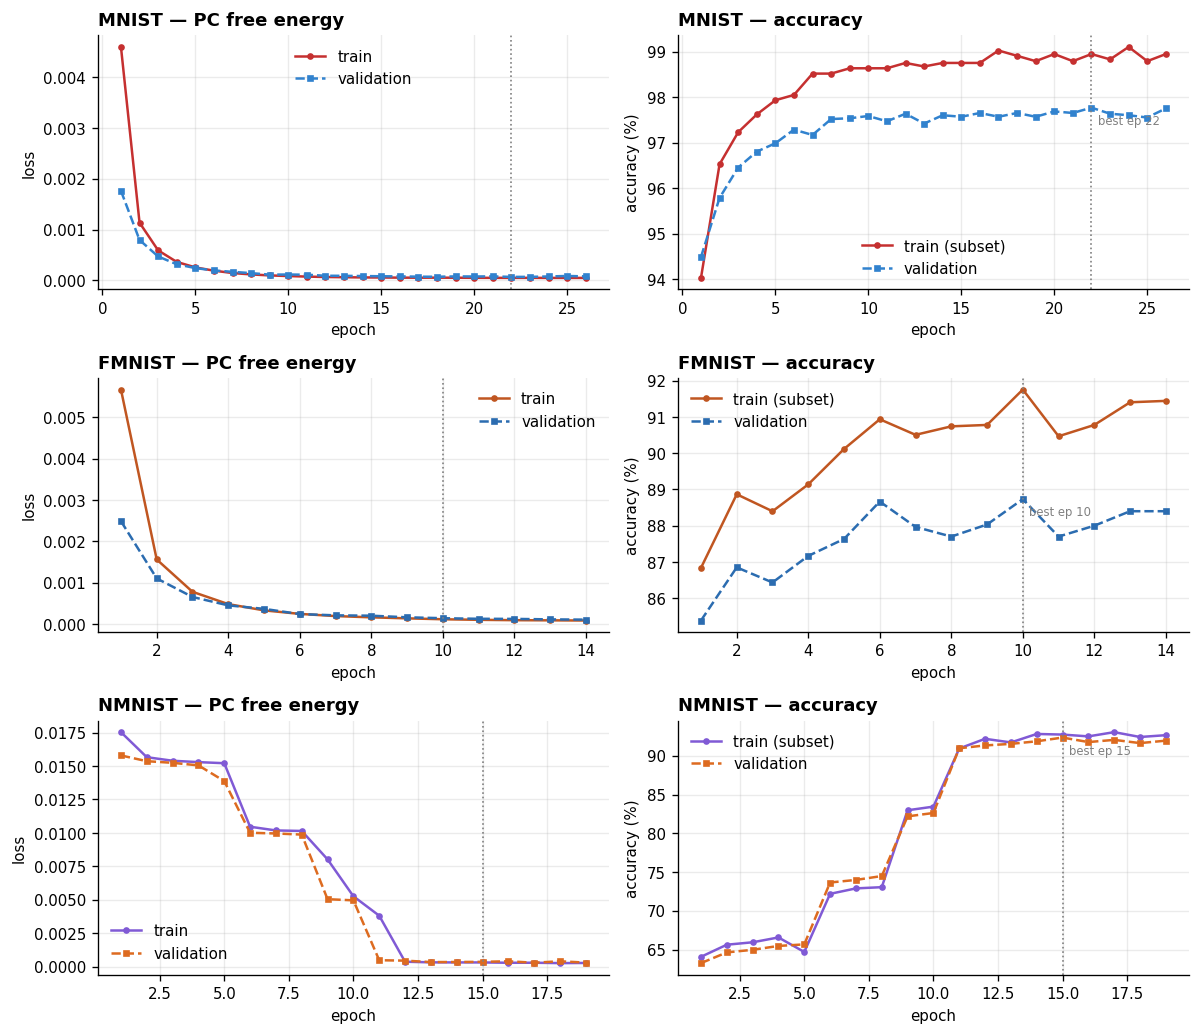

saved -> ./hhpc_results/curves_overlay.png


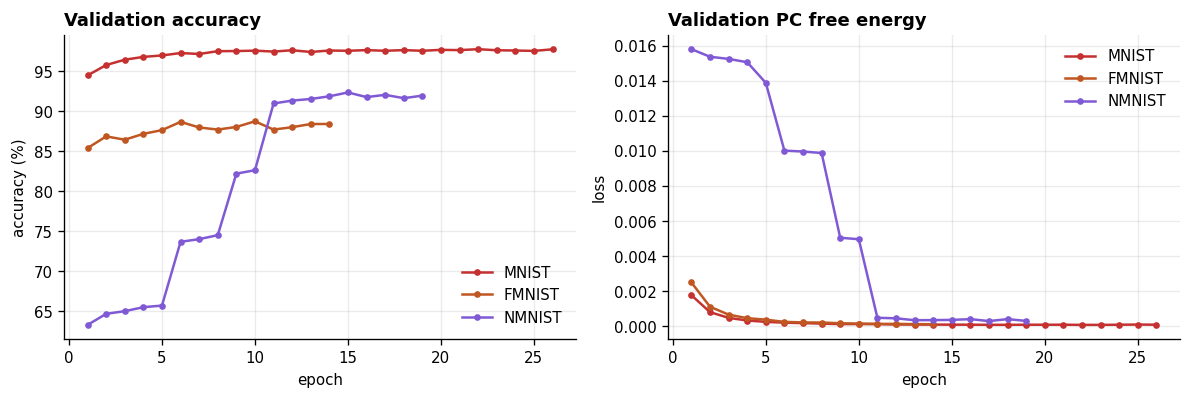

In [31]:
#@title Loss and accuracy curves per epoch
PALETTE = {
    "MNIST":   {"train": "#c53030", "val": "#3182ce"},  # red vs blue
    "FMNIST":  {"train": "#c05621", "val": "#2b6cb0"},  # orange vs blue
    #"CALTECH": {"train": "#2f855a", "val": "#d69e2e"},  # green vs gold
    "NMNIST":  {"train": "#805ad5", "val": "#dd6b20"},  # purple vs orange
}

def plot_training_curves(results: Dict[str, Any], save=True):
    names = [n for n in ["MNIST", "FMNIST", "NMNIST"] if n in results]
    if not names:
        print("No results yet — run the experiment cells first.")
        return
    fig, axes = plt.subplots(len(names), 2, figsize=(10, 2.9 * len(names)), squeeze=False)
    for r, name in enumerate(names):
        h = results[name]["history"]
        ep = h["epoch"]
        colors = PALETTE.get(name, {"train": "#444444", "val": "#888888"})
        best_ep = ep[int(np.argmax(h["val_acc"]))]

        ax = axes[r][0]
        ax.plot(ep, h["train_loss"], "-o", ms=3, color=colors["train"], label="train")
        ax.plot(ep, h["val_loss"], "--s", ms=3, color=colors["val"], label="validation")
        ax.axvline(best_ep, color="grey", ls=":", lw=1)
        ax.set_title(f"{name} — PC free energy", loc="left", fontweight="bold")
        ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend(frameon=False)

        ax = axes[r][1]
        ax.plot(ep, [a * 100 for a in h["train_acc"]], "-o", ms=3, color=colors["train"], label="train (subset)")
        ax.plot(ep, [a * 100 for a in h["val_acc"]], "--s", ms=3, color=colors["val"], label="validation")
        ax.axvline(best_ep, color="grey", ls=":", lw=1)
        ax.annotate(f"best ep {best_ep}", xy=(best_ep, max(h["val_acc"]) * 100),
                    xytext=(4, -10), textcoords="offset points", fontsize=7, color="grey")
        ax.set_title(f"{name} — accuracy", loc="left", fontweight="bold")
        ax.set_xlabel("epoch"); ax.set_ylabel("accuracy (%)"); ax.legend(frameon=False)
    fig.tight_layout()
    if save:
        p = os.path.join(OUT_DIR, "curves_loss_accuracy.png")
        fig.savefig(p, bbox_inches="tight"); print(f"saved -> {p}")
    plt.show()

def plot_val_accuracy_overlay(results: Dict[str, Any], save=True):
    names = [n for n in ["MNIST", "FMNIST","NMNIST"] if n in results]
    if not names:
        return
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    for name in names:
        h = results[name]["history"]
        col = PALETTE.get(name, {"train": "#444"})["train"]
        axes[0].plot(h["epoch"], [a * 100 for a in h["val_acc"]], "-o", ms=3, color=col, label=name)
        axes[1].plot(h["epoch"], h["val_loss"], "-o", ms=3, color=col, label=name)
    axes[0].set_title("Validation accuracy", loc="left", fontweight="bold")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy (%)"); axes[0].legend(frameon=False)
    axes[1].set_title("Validation PC free energy", loc="left", fontweight="bold")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss"); axes[1].legend(frameon=False)
    fig.tight_layout()
    if save:
        p = os.path.join(OUT_DIR, "curves_overlay.png")
        fig.savefig(p, bbox_inches="tight"); print(f"saved -> {p}")
    plt.show()

plot_training_curves(RESULTS)
plot_val_accuracy_overlay(RESULTS)

saved -> ./hhpc_results/roc_curves.png


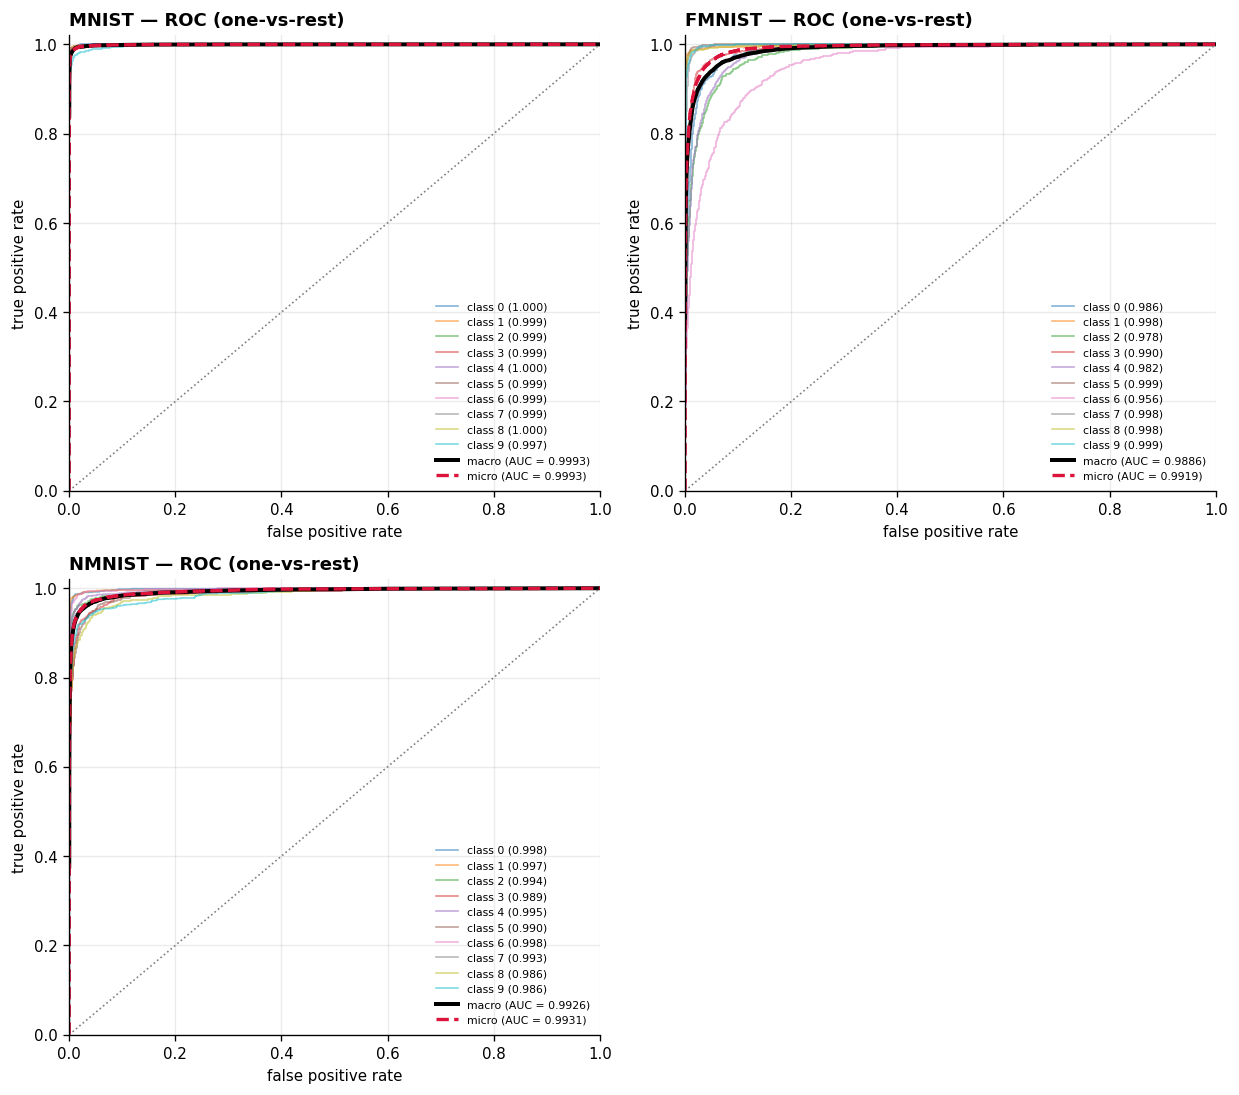

saved -> ./hhpc_results/roc_macro_comparison.png


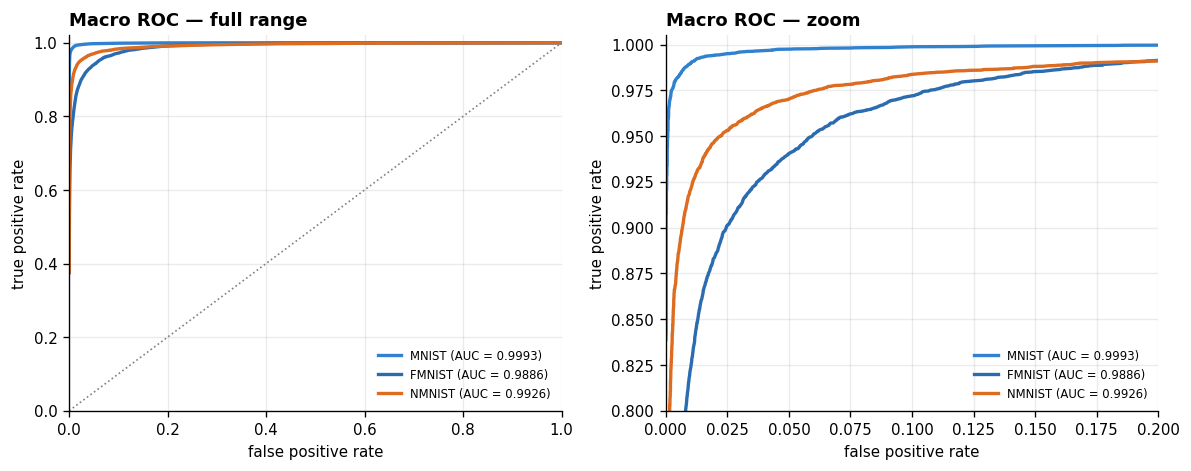

In [35]:
#@title ROC curves
def _get_color(name, fallback="#444444"):
    """PALETTE entries may be a plain color string or a dict of role->color.
    Always return a single valid matplotlib color."""
    c = PALETTE.get(name, fallback)
    if isinstance(c, dict):
        return c.get("val", c.get("test", next(iter(c.values()), fallback)))
    return c

def plot_roc(results: Dict[str, Any], save=True):
    names = [n for n in ["MNIST", "FMNIST", "NMNIST"] if n in results]
    if not names:
        print("No results yet — run the experiment cells first.")
        return
    ncol = min(2, len(names))
    nrow = int(math.ceil(len(names) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 4.6 * nrow), squeeze=False)
    for k, name in enumerate(names):
        ax = axes[k // ncol][k % ncol]
        roc = results[name]["roc"]
        C = roc["C"]
        if C == 2:
            b = roc["binary"]
            ax.plot(b["fpr"], b["tpr"], lw=2.2, color=_get_color(name, "#2f855a"),
                    label=f"Motorbikes vs Faces (AUC = {b['auc']:.4f})")
        else:
            cmap = plt.get_cmap("tab10")
            for c in sorted(roc["per_class"].keys()):
                d = roc["per_class"][c]
                ax.plot(d["fpr"], d["tpr"], lw=1.0, alpha=0.55, color=cmap(c % 10),
                        label=f"class {c} ({d['auc']:.3f})")
            ax.plot(roc["macro"]["fpr"], roc["macro"]["tpr"], lw=2.4, color="black",
                    label=f"macro (AUC = {roc['macro']['auc']:.4f})")
            ax.plot(roc["micro"]["fpr"], roc["micro"]["tpr"], lw=2.0, ls="--", color="crimson",
                    label=f"micro (AUC = {roc['micro']['auc']:.4f})")
        ax.plot([0, 1], [0, 1], ls=":", lw=1, color="grey")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
        ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
        ax.set_title(f"{name} — ROC (one-vs-rest)", loc="left", fontweight="bold")
        ax.legend(fontsize=6.5, loc="lower right", frameon=False, ncol=1)
    for j in range(len(names), nrow * ncol):
        axes[j // ncol][j % ncol].axis("off")
    fig.tight_layout()
    if save:
        p = os.path.join(OUT_DIR, "roc_curves.png")
        fig.savefig(p, bbox_inches="tight"); print(f"saved -> {p}")
    plt.show()

def plot_roc_zoom(results: Dict[str, Any], save=True):
    """Macro ROC for every dataset on one axis, zoomed into the top-left corner
    where well-performing classifiers actually differ."""
    names = [n for n in ["MNIST", "FMNIST", "NMNIST"] if n in results]
    if not names:
        return
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for name in names:
        roc = results[name]["roc"]
        d = roc["binary"] if roc["C"] == 2 else roc["macro"]
        for ax in axes:
            ax.plot(d["fpr"], d["tpr"], lw=2, color=_get_color(name, "#444444"),
                    label=f"{name} (AUC = {d['auc']:.4f})")
    axes[0].plot([0, 1], [0, 1], ls=":", lw=1, color="grey")
    axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02); axes[0].set_title("Macro ROC — full range", loc="left", fontweight="bold")
    axes[1].set_xlim(0, 0.2); axes[1].set_ylim(0.8, 1.005); axes[1].set_title("Macro ROC — zoom", loc="left", fontweight="bold")
    for ax in axes:
        ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
        ax.legend(fontsize=7, loc="lower right", frameon=False)
    fig.tight_layout()
    if save:
        p = os.path.join(OUT_DIR, "roc_macro_comparison.png")
        fig.savefig(p, bbox_inches="tight"); print(f"saved -> {p}")
    plt.show()

plot_roc(RESULTS)
plot_roc_zoom(RESULTS)

## 8. Summary tables

Two tables: the headline metrics you would put in a results table, and the full operation breakdown behind the FLOP/SOP columns. Both are written to CSV in `./hhpc_results/`.

In [36]:
#@title Summary tables
import pandas as pd


def summary_table(results: Dict[str, Any]) -> pd.DataFrame:
    rows = []
    for name in ["MNIST", "FMNIST", "NMNIST"]:
        if name not in results:
            continue
        r, t, o, roc = results[name], results[name]["test"], results[name]["ops"], results[name]["roc"]
        rows.append({
            "dataset": name,
            "classes": r["cfg"]["num_classes"],
            "test_n": t["n"],
            "accuracy_%": 100 * t["pc_acc"],
            "f1_macro": t["pc_f1_macro"],
            "f1_weighted": t["pc_f1_weighted"],
            "roc_auc_macro": roc["macro_auc"],
            "roc_auc_micro": roc["micro_auc"],
            "SOPs/sample": o["SOPs_per_sample"],
            "FLOPs/sample": o["FLOPs_per_sample"],
            "spike_rate": o["spike_rate_total"],
            "energy_uJ": o["energy_pJ_per_sample"] / 1e6,
            "ff_accuracy_%": 100 * t["ff_acc"],
            "epochs": r["epochs_run"],
            "train_min": r["train_time_s"] / 60,
        })
    return pd.DataFrame(rows).set_index("dataset")


def ops_table(results: Dict[str, Any]) -> pd.DataFrame:
    rows = []
    for name in ["MNIST", "FMNIST", "CALTECH", "NMNIST"]:
        if name not in results:
            continue
        o = results[name]["ops"]
        rows.append({
            "dataset": name,
            "input_spikes": o["input_spikes_per_sample"],
            "hidden_spikes": o["hidden_spikes_per_sample"],
            "output_spikes": o["output_spikes_per_sample"],
            "SOP_in->hidden": o["SOPs_layer1"],
            "SOP_hidden->out": o["SOPs_layer2"],
            "SOP_total": o["SOPs_per_sample"],
            "FLOP_hh": o["FLOPs_hh_dynamics"],
            "FLOP_bias": o["FLOPs_bias_current"],
            "FLOP_pc_infer": o["FLOPs_pc_inference"],
            "FLOP_total": o["FLOPs_per_sample"],
            "FLOP_dense_ann": o["FLOPs_ann_equivalent"],
            "SOP/FLOP_ratio": o["SOPs_per_sample"] / max(o["FLOPs_per_sample"], 1),
        })
    return pd.DataFrame(rows).set_index("dataset")


if RESULTS:
    pd.set_option("display.width", 200, "display.max_columns", 50, "display.float_format", lambda v: f"{v:,.4f}")

    summary = summary_table(RESULTS)
    ops = ops_table(RESULTS)

    print("── HEADLINE METRICS " + "─" * 58)
    display(summary.style.format({
        "accuracy_%": "{:.2f}", "ff_accuracy_%": "{:.2f}", "f1_macro": "{:.4f}",
        "f1_weighted": "{:.4f}", "roc_auc_macro": "{:.4f}", "roc_auc_micro": "{:.4f}",
        "SOPs/sample": "{:,.0f}", "FLOPs/sample": "{:,.0f}", "spike_rate": "{:.4f}",
        "energy_uJ": "{:.3f}", "train_min": "{:.1f}",
    }))

    print("\n── OPERATION BREAKDOWN (per test sample) " + "─" * 37)
    display(ops.style.format({c: "{:,.0f}" for c in ops.columns if c != "SOP/FLOP_ratio"}
                             | {"SOP/FLOP_ratio": "{:.3f}"}))

    summary.to_csv(os.path.join(OUT_DIR, "summary_metrics.csv"))
    ops.to_csv(os.path.join(OUT_DIR, "operation_breakdown.csv"))
    print(f"\nsaved -> {OUT_DIR}/summary_metrics.csv and operation_breakdown.csv")
else:
    print("No results yet — run the experiment cells first.")

── HEADLINE METRICS ──────────────────────────────────────────────────────────


,classes,test_n,accuracy_%,f1_macro,f1_weighted,roc_auc_macro,roc_auc_micro,SOPs/sample,FLOPs/sample,spike_rate,energy_uJ,ff_accuracy_%,epochs,train_min
dataset,,,,,,,,,,,,,,
MNIST,10,10000,97.72,0.9771,0.9772,0.9993,0.9993,"3,193,431","46,077,820",0.0061,108.853,9.93,26,43.4
FMNIST,10,10000,88.08,0.8788,0.8788,0.9885,0.9919,"6,910,524","46,077,820",0.0062,112.198,10.00,14,23.4
NMNIST,10,10000,92.56,0.9242,0.9253,0.9926,0.9931,"1,773,380","125,099,640",0.0134,289.325,15.64,19,79.0



── OPERATION BREAKDOWN (per test sample) ─────────────────────────────────────


,input_spikes,hidden_spikes,output_spikes,SOP_in->hidden,SOP_hidden->out,SOP_total,FLOP_hh,FLOP_bias,FLOP_pc_infer,FLOP_total,FLOP_dense_ann,SOP/FLOP_ratio
dataset,,,,,,,,,,,,
MNIST,"6,234",184,7,"3,191,589","1,842","3,193,431","4,666,680","62,640","41,348,500","46,077,820","813,056",0.069
FMNIST,"13,494",184,10,"6,908,682","1,842","6,910,524","4,666,680","62,640","41,348,500","46,077,820","813,056",0.150
NMNIST,"3,454",481,8,"1,768,574","4,806","1,773,380","5,444,460","73,080","119,582,100","125,099,640","2,377,728",0.014



saved -> ./hhpc_results/summary_metrics.csv and operation_breakdown.csv


saved -> ./hhpc_results/confusion_matrices.png


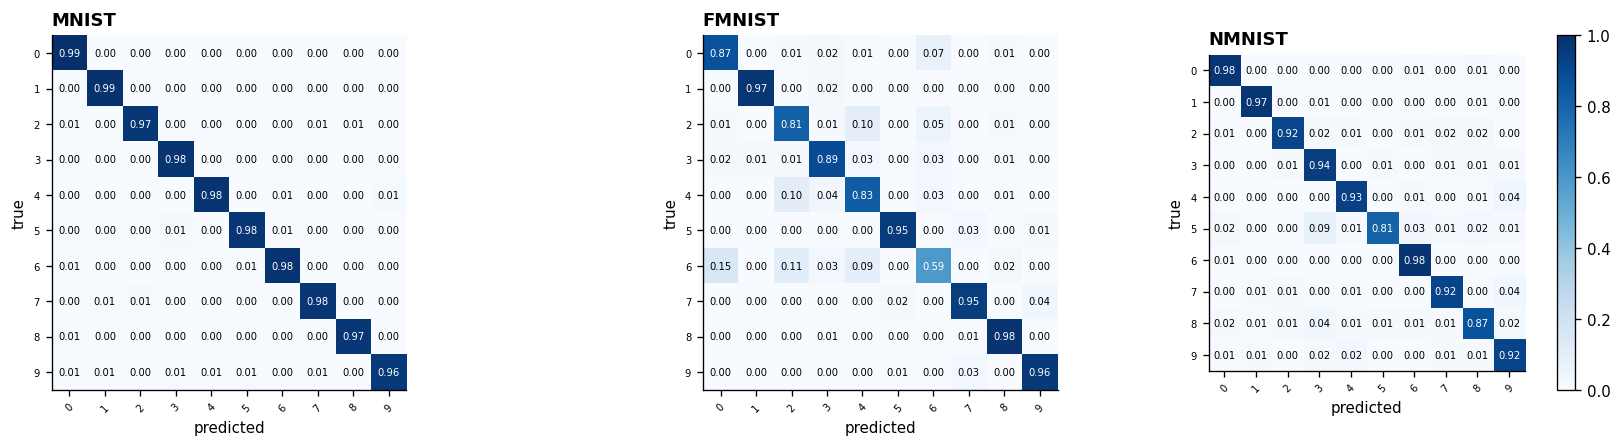

saved -> ./hhpc_results/operation_counts.png


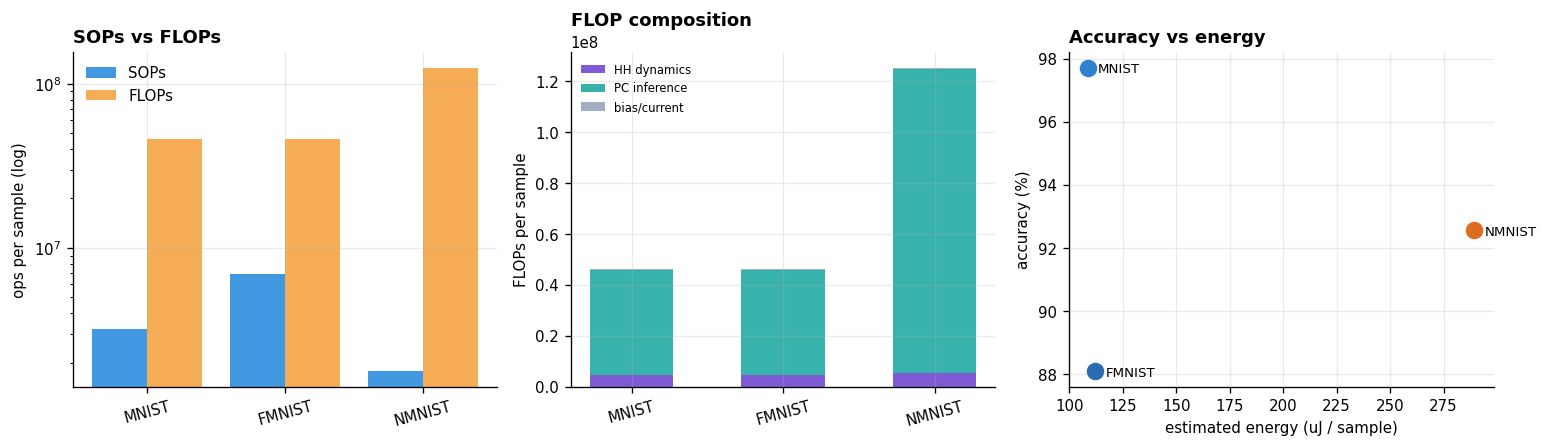

In [38]:
#@title Operation-count comparison and confusion matrices

def _get_color(name, fallback="#444444"):
    """PALETTE entries may be a plain color string or a dict of role->color.
    Always return a single valid matplotlib color."""
    c = PALETTE.get(name, fallback)
    if isinstance(c, dict):
        return c.get("val", c.get("test", next(iter(c.values()), fallback)))
    return c


def plot_ops(results: Dict[str, Any], save=True):
    names = [n for n in ["MNIST", "FMNIST", "NMNIST"] if n in results]
    if not names:
        print("No results yet.")
        return

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    x = np.arange(len(names))

    sops = [results[n]["ops"]["SOPs_per_sample"] for n in names]
    flops = [results[n]["ops"]["FLOPs_per_sample"] for n in names]
    axes[0].bar(x - 0.2, sops, 0.4, label="SOPs", color="#4299e1")
    axes[0].bar(x + 0.2, flops, 0.4, label="FLOPs", color="#f6ad55")
    axes[0].set_yscale("log"); axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15)
    axes[0].set_ylabel("ops per sample (log)")
    axes[0].set_title("SOPs vs FLOPs", loc="left", fontweight="bold"); axes[0].legend(frameon=False)

    # where the FLOPs actually go
    hh = [results[n]["ops"]["FLOPs_hh_dynamics"] for n in names]
    pc = [results[n]["ops"]["FLOPs_pc_inference"] for n in names]
    bi = [results[n]["ops"]["FLOPs_bias_current"] for n in names]
    axes[1].bar(x, hh, 0.55, label="HH dynamics", color="#805ad5")
    axes[1].bar(x, pc, 0.55, bottom=hh, label="PC inference", color="#38b2ac")
    axes[1].bar(x, bi, 0.55, bottom=np.array(hh) + np.array(pc), label="bias/current", color="#a0aec0")
    axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15)
    axes[1].set_ylabel("FLOPs per sample")
    axes[1].set_title("FLOP composition", loc="left", fontweight="bold"); axes[1].legend(frameon=False, fontsize=7)

    acc = [100 * results[n]["test"]["pc_acc"] for n in names]
    en  = [results[n]["ops"]["energy_pJ_per_sample"] / 1e6 for n in names]
    for i, n in enumerate(names):
        axes[2].scatter(en[i], acc[i], s=90, color=_get_color(n, "#444444"), zorder=3)
        axes[2].annotate(n, (en[i], acc[i]), xytext=(6, -3), textcoords="offset points", fontsize=8)
    axes[2].set_xlabel("estimated energy (uJ / sample)"); axes[2].set_ylabel("accuracy (%)")
    axes[2].set_title("Accuracy vs energy", loc="left", fontweight="bold")

    fig.tight_layout()
    if save:
        p = os.path.join(OUT_DIR, "operation_counts.png")
        fig.savefig(p, bbox_inches="tight"); print(f"saved -> {p}")
    plt.show()


def plot_confusions(results: Dict[str, Any], save=True):
    names = [n for n in ["MNIST", "FMNIST", "NMNIST"] if n in results]
    if not names:
        return

    # give each panel width proportional to its number of classes
    class_counts = [results[n]["cfg"]["num_classes"] for n in names]
    width_ratios = [max(c, 3) for c in class_counts]  # floor so 2-class panels aren't too thin

    fig, axes = plt.subplots(
        1, len(names),
        figsize=(sum(width_ratios) * 0.55, 3.8),
        gridspec_kw={'width_ratios': width_ratios},
        squeeze=False
    )

    for k, name in enumerate(names):
        t = results[name]["test"]
        C = results[name]["cfg"]["num_classes"]
        cm = confusion_matrix(t["y_true"], t["y_pred"], labels=list(range(C)))
        cmn = cm / np.clip(cm.sum(1, keepdims=True), 1, None)
        ax = axes[0][k]
        im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        ax.set_title(f"{name}", loc="left", fontweight="bold")
        ax.set_xlabel("predicted"); ax.set_ylabel("true")
        ax.grid(False)

        labels = [str(i) for i in range(C)]
        ax.set_xticks(range(C)); ax.set_xticklabels(labels, fontsize=6, rotation=45)
        ax.set_yticks(range(C)); ax.set_yticklabels(labels, fontsize=6)

        fontsize = 7 if C <= 4 else 6
        for a in range(C):
            for b in range(C):
                val = cmn[a, b]
                ax.text(
                    b, a, f"{val:.2f}",
                    ha="center", va="center", fontsize=fontsize,
                    color="white" if val > 0.5 else "black"
                )

    fig.colorbar(im, ax=axes[0][-1], fraction=0.46)
    fig.tight_layout()
    if save:
        p = os.path.join(OUT_DIR, "confusion_matrices.png")
        fig.savefig(p, bbox_inches="tight"); print(f"saved -> {p}")
    plt.show()

plot_confusions(RESULTS)
plot_ops(RESULTS)

## 9. Notes for reporting

**Which accuracy is the model's accuracy.** `pc_acc` is the headline number: the output layer after predictive-coding relaxation with the label unclamped. `ff_acc` — the raw output firing rate — is reported alongside because the gap between them tells you how much work the PC relaxation is actually doing. If they are identical, the relaxation is not contributing and `T_infer_eval` can be cut.

**Caltech is small and imbalanced.** Faces (~435) vs Motorbikes (~798) is roughly 35/65. Read `f1_macro` rather than accuracy there, and note that a majority-class predictor already gets ~65%. The stratified split keeps that ratio in all three folds.

**N-MNIST is not MNIST with noise.** It is a different input distribution entirely — 2312 event channels, temporally structured, driven by saccadic camera motion. It gets its own `input_dim`, so its FLOP and SOP numbers are not directly comparable to the 784-input datasets on an absolute scale. Compare spike *rates* and SOP/FLOP *ratios* across datasets, not raw counts.

**Expect PC inference, not HH, to dominate the FLOP count.** Work the arithmetic for MNIST at the default settings: HH dynamics cost `50 steps × 522 neurons × 149 ≈ 3.9 MFLOP`, while PC inference costs `50 iterations × ~2 × 784 × 512 ≈ 41 MFLOP` — an order of magnitude more. The reason is that `pc_infer` recomputes the full input→hidden matmul on *every* relaxation iteration, and that matrix is by far the largest thing in the network.

Two consequences worth stating explicitly in a write-up:

- `T_infer_eval` is the single biggest cost lever, not `steps_spk`. Sweeping it and showing accuracy is flat past some value is a cheap, strong result.
- Any claim that this model is energy-efficient has to survive the PC inference term. The SOP count alone (~2.6 M/sample for MNIST) looks favourable; the total picture does not, unless the relaxation is shortened. Report both or the comparison is not honest.

The HH term is still what separates this from a LIF baseline — a LIF update is roughly 10–15 FLOPs against 149 here — so it matters for that specific comparison even though it is not the dominant term overall.

**Reproducibility.** Every evaluation forks the RNG and reseeds to `eval_seed=1234`, so the Poisson input trains are identical across runs and across models. That matters — without it, spike-count and accuracy numbers drift between runs purely from encoding noise.

**Sensible next steps**
- Add a LIF and a non-spiking control by swapping the cell type, so the FLOP table has something to be compared against.
- Run 3–5 seeds per dataset and report mean ± std; single-seed SNN numbers are noisy.
- Sweep `steps_spk` ∈ {10, 25, 50, 100} to get an accuracy-vs-SOP Pareto curve, which is usually the most convincing figure in this kind of paper.